<a href="https://colab.research.google.com/github/amer-baniodeh/project-1-deep-learning-image-classification-with-cnn/blob/main/model_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model 10 - Transfer Learning with EfficientNetB0
with resizing images (96,96), Data Augmentation and Upscaling.

<br>

- accuracy: 0.9092 - loss: 0.2588 - val_accuracy: 0.8853 - val_loss: 0.3599

    - 15mins - 20 + 10 epochs
    - Fine Tuning + Adv Learning Rate Scheduler
    + change to Flatten, higher Dropout and Wider Dense 256

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, Resizing, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from google.colab import drive

# ---------------------------------------------------
# 1. Load Data
# ---------------------------------------------------
drive.mount('/content/drive')

x_train_raw = np.load('/content/drive/MyDrive/IronHack/datasets/cifar10_data/x_train.npy')
y_train_raw = np.load('/content/drive/MyDrive/IronHack/datasets/cifar10_data/y_train.npy')
x_test_raw = np.load('/content/drive/MyDrive/IronHack/datasets/cifar10_data/x_test.npy')
y_test_raw = np.load('/content/drive/MyDrive/IronHack/datasets/cifar10_data/y_test.npy')



# ---------------------------------------------------
# 2. Train / Validation Split & One-Hot Encoding
# ---------------------------------------------------
x_train_raw, x_val_raw, y_train, y_val = train_test_split(
    x_train_raw, y_train_raw, test_size=0.2, random_state=42, stratify=y_train_raw
)

num_classes = 10
y_train_one_hot = to_categorical(y_train, num_classes)
y_val_one_hot = to_categorical(y_val, num_classes)
y_test_one_hot = to_categorical(y_test_raw, num_classes)


# Verify the shapes to make sure everything loaded correctly
print(f"x_train_raw shape: {x_train_raw.shape} | y_train_raw shape: {y_train_raw.shape}")
print(f"x_val_raw shape: {x_val_raw.shape} | y_train shape: {y_train.shape}")

print(f"y_train_one_hot shape: {y_train_one_hot.shape}")
print(f"y_val_one_hot shape: {y_val_one_hot.shape}")
print(f"y_test_one_hot shape: {y_test_one_hot.shape}")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
x_train_raw shape: (40000, 32, 32, 3) | y_train_raw shape: (50000, 1)
x_val_raw shape: (10000, 32, 32, 3) | y_train shape: (40000, 1)
y_train_one_hot shape: (40000, 10)
y_val_one_hot shape: (10000, 10)
y_test_one_hot shape: (10000, 10)


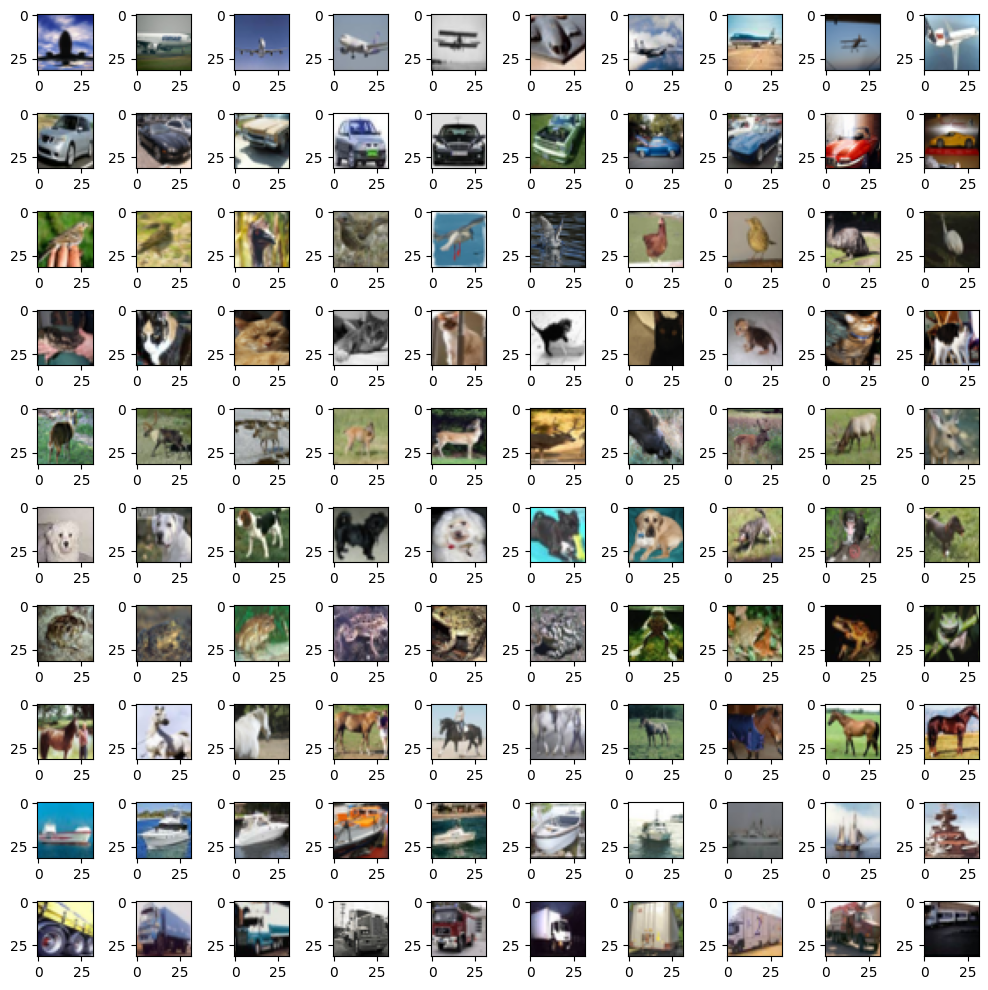

In [2]:
plt.figure(figsize=(10, 10))

for class_id in range(10):
    class_indices = np.where(y_train == class_id)[0]

    # Grab 10 samples for this class
    for sample_idx in range(10):
        # Calculate the 1-indexed grid position (1 to 100)
        position = (class_id * 10) + sample_idx + 1
        img_index = class_indices[sample_idx]

        plt.subplot(10, 10, position)
        plt.imshow(x_train_raw[img_index])
        plt.axis('on')

plt.tight_layout()
plt.show()

In [3]:
# ---------------------------------------------------
# 3. Clean Preprocessing (No manual division by 255!)
# ---------------------------------------------------
x_train = preprocess_input(x_train_raw.astype('float32'))
x_val = preprocess_input(x_val_raw.astype('float32'))
x_test = preprocess_input(x_test_raw.astype('float32'))

In [4]:
from tensorflow.keras.layers import Flatten

# ---------------------------------------------------
# 4. Build Model Architecture with EfficientNetB0
# ---------------------------------------------------
# Data Augmentation (Kept gentle for CIFAR-10)
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomZoom(0.05),
], name="data_augmentation")

# Base Model (Input shape 96x96 matching our resizing step)
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)
base_model.trainable = False  # Freeze base layers first

# Connecting the pipeline
inputs = Input(shape=(32, 32, 3))
x = data_augmentation(inputs)
x = Resizing(96, 96, interpolation="bilinear")(x)
x = base_model(x, training=False)
x = Flatten()(x) # <-- Replaces GlobalAveragePooling2D()
x = Dropout(0.4)(x) # Slightly higher dropout since Flatten increases parameters
x = Dense(256, activation='relu')(x) # Increased from 128 to 256 units
outputs = Dense(10, activation='softmax')(x)

model_effnet = Model(inputs, outputs)

In [5]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Advanced Learning Rate Scheduler (ReduceLROnPlateau)
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,          # Multiply LR by 0.2 when stuck (e.g., 1e-3 drops to 2e-4)
    patience=2,          # Number of epochs to wait before dropping LR
    verbose=1,
    min_lr=1e-6
)

# ---------------------------------------------------
# 5. Phase 1 Training: Feature Extraction (Top Frozen)
# ---------------------------------------------------
model_effnet.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting Phase 1 Training...")
history = model_effnet.fit(
    x_train, y_train_one_hot,
    validation_data=(x_val, y_val_one_hot),  # Strictly using x_val here
    epochs=20,
    batch_size=64,
    callbacks=[lr_scheduler]
)


Starting Phase 1 Training...
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.7516 - loss: 0.7309 - val_accuracy: 0.8600 - val_loss: 0.4108 - learning_rate: 0.0010
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.8080 - loss: 0.5481 - val_accuracy: 0.8659 - val_loss: 0.3885 - learning_rate: 0.0010
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.8280 - loss: 0.4944 - val_accuracy: 0.8646 - val_loss: 0.4044 - learning_rate: 0.0010
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8426 - loss: 0.4520
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.8384 - loss: 0.4679 - val_accuracy: 0.8699 - val_loss: 0.3885 - learning_rate: 0.0010
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.8686 - loss: 0.3800 - val_accuracy: 0.8783 - val_loss: 0.3636 - learning_rate: 2.0000e-04
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 

In [6]:


# ---------------------------------------------------
# 6. Phase 2 Training: Fine-Tuning (Top Unfrozen)
# ---------------------------------------------------
base_model.trainable = True

# Freeze everything except the top 50 layers of EfficientNetB0
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Recompile with low learning rate
model_effnet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting Phase 2 Fine-Tuning...")
history_fine = model_effnet.fit(
    x_train, y_train_one_hot,
    validation_data=(x_val, y_val_one_hot),
    epochs=10,
    batch_size=64,
    callbacks=[lr_scheduler]
)


# ---------------------------------------------------
# 6 Phase 3: Deeper Fine-Tuning (Top 100 Layers)
# ---------------------------------------------------
#base_model.trainable = True
#
# Freeze everything except the top 100 layers
#for layer in base_model.layers[:-100]:
#    layer.trainable = False
#

# Keep learning rate ultra-low to preserve early edge detectors
#model_effnet.compile(
#    optimizer=Adam(learning_rate=5e-6),
#    loss='categorical_crossentropy',
#    metrics=['accuracy']
#)
#
#print("Starting Phase 3 Deep Fine-Tuning...")
#history_fine_deep = model_effnet.fit(
#    x_train, y_train_one_hot,
#    validation_data=(x_val, y_val_one_hot),
#    epochs=10,
#    batch_size=64
#)


Starting Phase 2 Fine-Tuning...
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 56ms/step - accuracy: 0.7491 - loss: 1.3975 - val_accuracy: 0.8260 - val_loss: 0.9227 - learning_rate: 1.0000e-05
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7894 - loss: 1.0088
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.7931 - loss: 0.9825 - val_accuracy: 0.8389 - val_loss: 0.8010 - learning_rate: 1.0000e-05
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.8072 - loss: 0.8511 - val_accuracy: 0.8407 - val_loss: 0.7813 - learning_rate: 2.0000e-06
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8012 - loss: 0.8812
Epoch 4: ReduceLROnPlateau reducing learning rate to 1e-06.
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.8057 - loss: 0.8462 - val_accuracy: 0.8437 - val_loss: 0.7572 - learning_rate: 2.0000e-06
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 50m

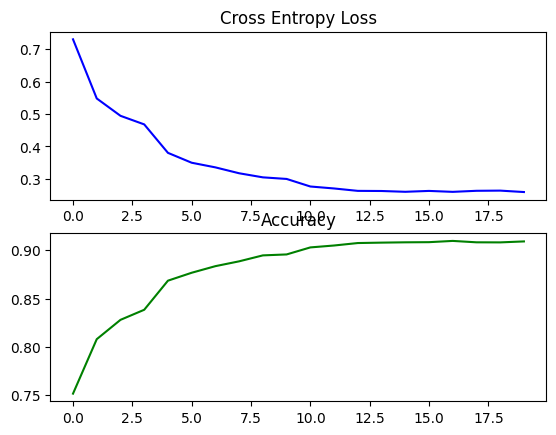

In [7]:
#Plot the cross entropy loss curve and the accuracy curve
plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(history.history['loss'], color='blue', label='train')

plt.subplot(212)
plt.title('Accuracy')
plt.plot(history.history['accuracy'], color='green', label='train')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step
True label counts:      [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]
Predicted label counts: [ 944 1013  925  864 1027 1093 1087  986 1007 1054]


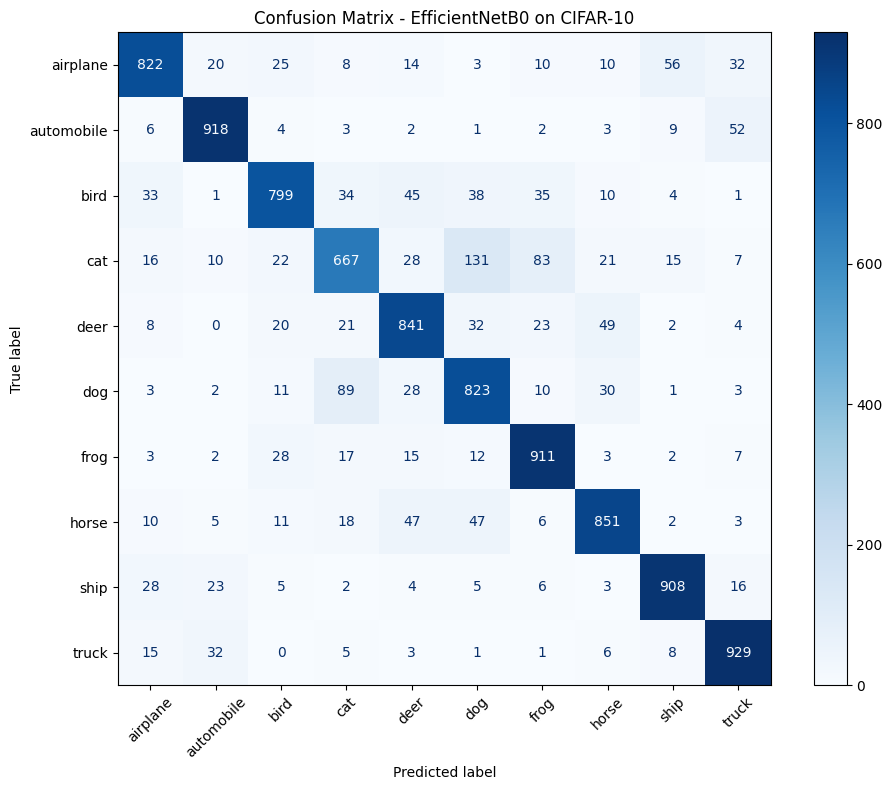

In [8]:
# ---------------------------------------------------
# 7. Evaluate and Generate Confusion Matrix
# ---------------------------------------------------
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Predictions on validation dataset
y_pred_prob = model_effnet.predict(x_val)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_val.flatten()

# Print diagnostics to check performance stability
print("True label counts:     ", np.bincount(y_true))
print("Predicted label counts:", np.bincount(y_pred))

# Plotting the matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Blues', xticks_rotation=45, ax=ax)
plt.title("Confusion Matrix - EfficientNetB0 on CIFAR-10")
plt.tight_layout()
plt.show()

In [9]:
# Saving Model in Google Drive

model_effnet.save("/content/drive/MyDrive/IronHack/Models/model_10_effnet.keras")
print("Model saved successfully!")



Model saved successfully!


In [10]:

from tensorflow.keras.models import load_model

# Checking that the saved model file is Valid
m = load_model("/content/drive/MyDrive/IronHack/Models/model_10_effnet.keras")
print("Loaded successfully")


#################################
# OPTIONAL PICKLE INSTRUCTIONS
#################################
# import pickle
#
#model_path = "/content/drive/MyDrive/Models/model_3.keras"
#
#with open(model_path, "wb") as f:
#    pickle.dump(model, f)
#
#print("Model saved to:", model_path)
#
#
#with open(model_path, "rb") as f:
#    loaded_model = pickle.load(f)
#
#print("Model loaded successfully!")
#


Loaded successfully
